In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd

In [3]:
stw1, stw2 = 7077176154, 7077178969

In [4]:
from pathlib import Path

from odin.level0.acfile import ACfile
from odin.level0.attfile import AttFile
from odin.level0.fbafile import FBAfile
from odin.level0.shkfile import SHKfile
from odin.level1.process import Level1

file = Path("./data/1a5d2ae7.ac1")
ac = ACfile(file).dataframe
att = AttFile(Path("./data/1a5c499d.att")).dataframe
shk = SHKfile(Path("./data/1a5d2ae9.shk")).dataframe
fba = FBAfile(Path("./data/1a5d2ae8.fba")).dataframe

Applying overflow correction
datetime    datetime64[ms, UTC]
stw                      uint64
orbit                   float64
qt                       object
qa                       object
qe                       object
gps                      object
os_pos                   object
smr_pos                  object
sci                      uint16
mode                     uint16
acs                     float64
dtype: object


In [5]:
l1 = Level1(
    ac=ac,
    att=att,
    shk=shk,
    fba=fba,
)

uint64 uint64
int64
30.360964 29.986813 30.670574
(4608,) (4396,) (204,) (9215,)
stw
7077015155     68.809528
7077015219     65.972528
7077015283     63.133882
7077015347     60.283294
7077015411     57.425117
                 ...    
7077309643    115.463704
7077309707    118.204353
7077309771    120.931467
7077309835    123.639885
7077309899    126.337411
Name: t_height, Length: 4608, dtype: float64
(4608, 8, 112) float64


/workspace/odin/src/odin/level1/intensity_calibration.py:51: RuntimeWarning: invalid value encountered in divide
  W = np.nanmedian(span, axis=-1, keepdims=True) / span
/workspace/odin/src/odin/level1/intensity_calibration.py:52: RuntimeWarning: All-NaN slice encountered
  W = W / np.nanmedian(W, axis=-1, keepdims=True)
/workspace/odin/src/odin/level1/intensity_calibration.py:81: RuntimeWarning: invalid value encountered in log1p
  return np.where(Jb > 0, T0 / np.log1p(T0 / Jb), 0.0)


## Sweeps identification

In [6]:
# sync = l1.shk["ACDC1 sync"].astype("uint16").to_numpy() >> 3 & 0xF
# print(sync[40:60])
# mask = np.where((sync == 5) |  (sync == 10) )
# stws = l1.ac.index[mask]
# stws

In [7]:
def stitch_full_band(x: np.ndarray, y: np.ndarray):
    """
    x, y: (n, 8, 112)
    returns: x_full, y_full: (n, 896) where x_full is monotonic increasing per row
    """
    assert x.shape == y.shape
    n = x.shape[0]

    X = x.reshape(n, -1)  # (n, 896)
    Y = y.reshape(n, -1)  # (n, 896)

    # If x can contain NaNs, push them to the end (optional)
    X_for_sort = np.where(np.isnan(X), np.inf, X)

    idx = np.argsort(X_for_sort, axis=1, kind="mergesort")  # stable sort
    rows = np.arange(n)[:, None]

    X_full = X[rows, idx]
    Y_full = Y[rows, idx]
    return X_full, Y_full

In [8]:
l1.calibrated.loc[stw1:stw2]

,calibrated
stw,
7077176186,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7077176250,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7077176314,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7077176378,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7077176442,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7077176506,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7077176570,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7077176634,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7077176698,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."


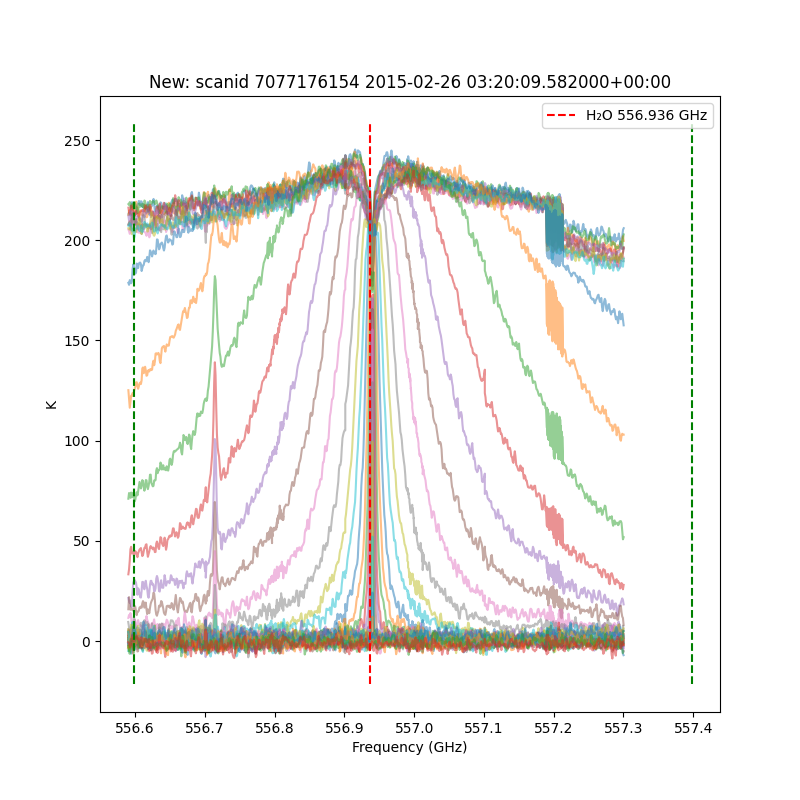

In [9]:
import matplotlib.pyplot as plt
plt.close("all")

freq = np.stack(
    l1.frequency_grid["frequency_grid"].loc[stw1:stw2].to_numpy()
).astype(np.float64)
cal = np.stack(l1.calibrated["calibrated"].loc[stw1:stw2].to_numpy())


fig, ax = plt.subplots(figsize=(8, 8))
x, y = stitch_full_band(freq, cal)
ax.plot(
    x.T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y.T,
    # ls="none",
    # marker=".",
    alpha=0.5,
)

if l1.ac.backend.iloc[0] == "AC1":
    ax.vlines(
            x=[556.936, 556.598, 557.398],
            ymin=ax.get_ylim()[0],
            ymax=ax.get_ylim()[1],
            colors=["r","g","g"],
            linestyles="--",
            label="H₂O 556.936 GHz",
        )
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"New: scanid {stw1} {l1.attitude.datetime.loc[stw1]}")
ax.set_ylabel("K")
plt.show()

In [10]:
import json

l1b = json.loads(Path("./data/l1b_spectrum.json").read_text())
LO_freq = np.array(l1b["Frequency"]["LOFreq"])
if_freq = np.array(l1b["Frequency"]["IFreqGrid"])
data = np.array(l1b["Spectrum"])
stw = np.array(l1b["STW"])
alt = np.array(l1b["Altitude"])

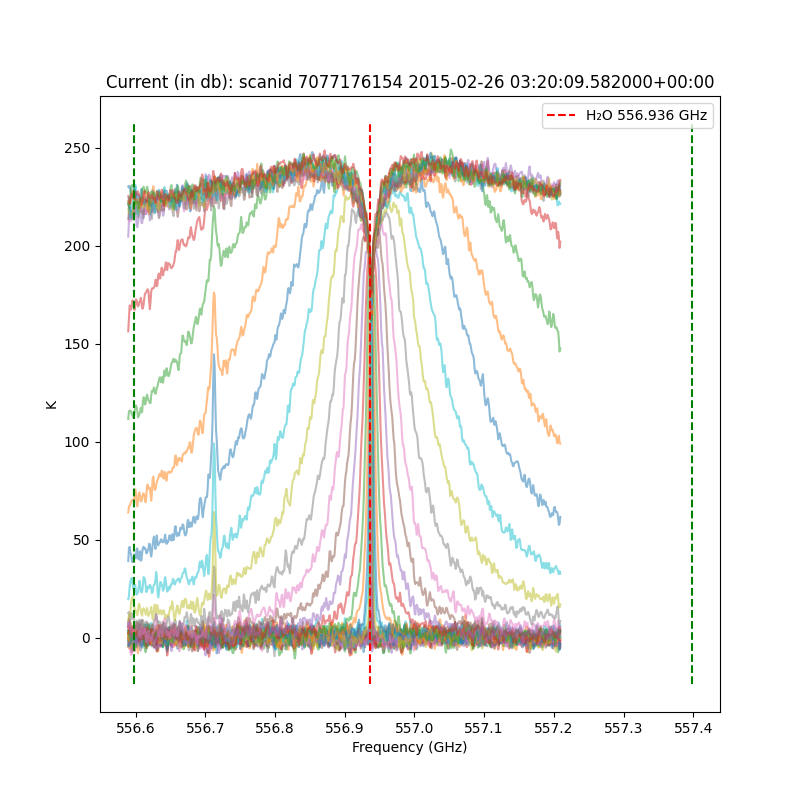

In [11]:
fig,ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[:,None] + if_freq[None,:] ).T/1e9,
    data.T,
    alpha=0.5,)

ax.vlines(
        x=[556.936, 556.598, 557.398],
        ymin=ax.get_ylim()[0],
        ymax=ax.get_ylim()[1],
        colors=["r","g","g"],
        linestyles="--",
        label="H₂O 556.936 GHz",
    )
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"Current (in db): scanid {stw1} {l1.attitude.datetime.loc[stw1]}")
ax.set_ylabel("K")
plt.show()

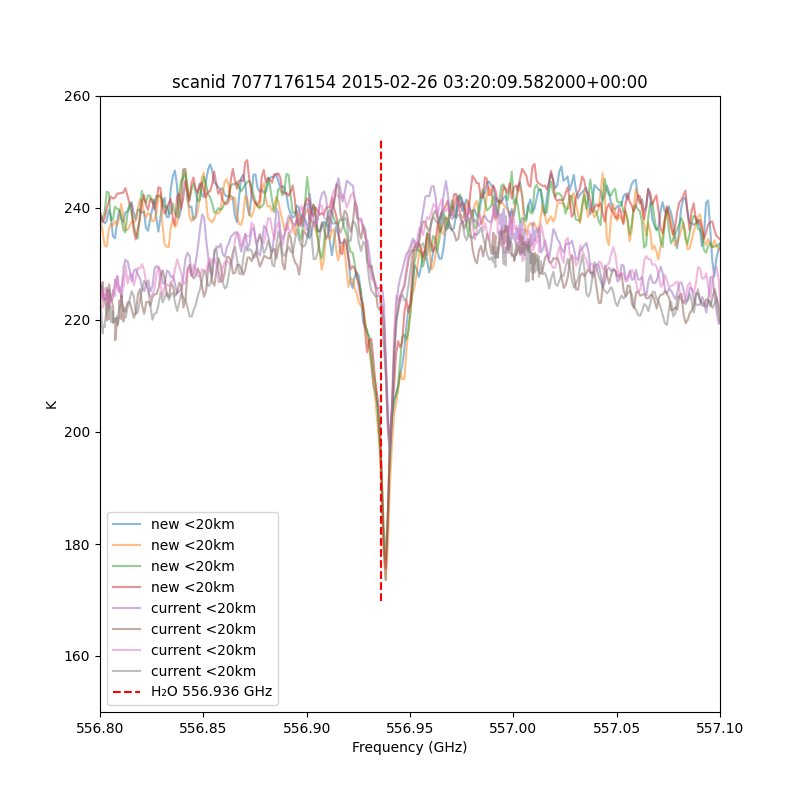

In [12]:
low_mask = (l1.specs.loc[stw1:stw2].t_height < 20).to_numpy()
low_mask_db = alt<20000
fig,ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[low_mask_db][:,None] + if_freq[None,:] ).T/1e9,
    data[low_mask_db].T,
    alpha=0.5,
    label="new <20km",
    )
ax.plot(
    x[low_mask].T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y[low_mask].T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    label="current <20km",
)
ax.vlines(
        x=[556.936, 556.598, 557.398],
        ymin=ax.get_ylim()[0],
        ymax=ax.get_ylim()[1],
        colors=["r","g","g"],
        linestyles="--",
        label="H₂O 556.936 GHz",
    )
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"scanid {stw1} {l1.attitude.datetime.loc[stw1]}")
ax.set_ylabel("K")
ax.set_xlim(556.8,557.1)
ax.set_ylim(150,260)
plt.show()

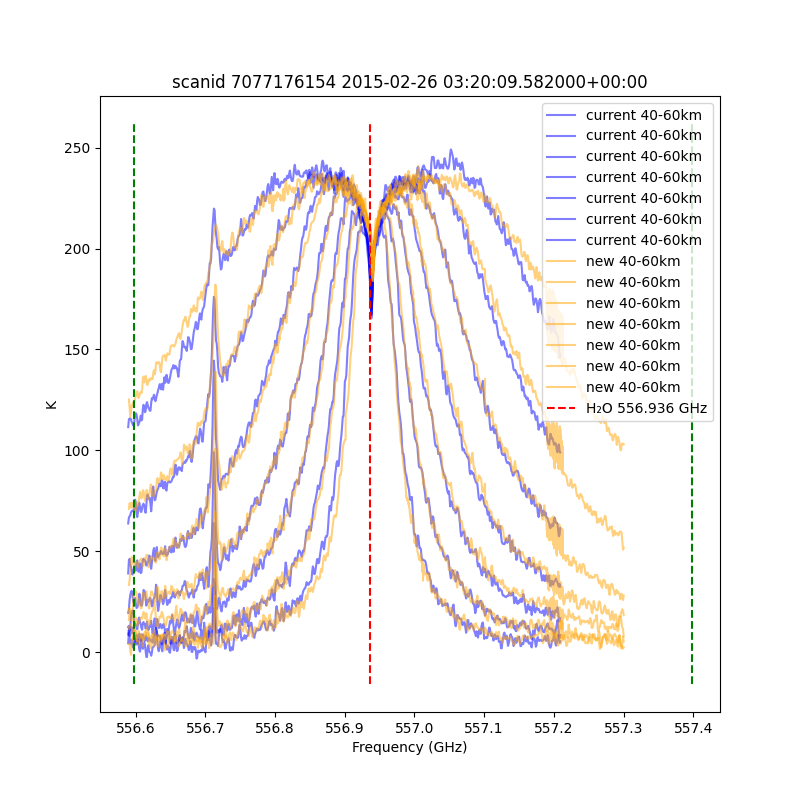

In [13]:
low_mask = (
    (l1.specs.loc[stw1:stw2].t_height > 40) & (l1.specs.loc[stw1:stw2].t_height < 60)
).to_numpy()
low_mask_db = (alt < 60000) & (alt > 40000)
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[low_mask_db][:, None] + if_freq[None, :]).T / 1e9,
    data[low_mask_db].T,
    alpha=0.5,
    color="blue",
    label="current 40-60km",
)
ax.plot(
    x[low_mask].T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y[low_mask].T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    color="orange",
    label="new 40-60km",
)
ax.vlines(
    x=[556.936, 556.598, 557.398],
    ymin=ax.get_ylim()[0],
    ymax=ax.get_ylim()[1],
    colors=["r", "g", "g"],
    linestyles="--",
    label="H₂O 556.936 GHz",
)
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"scanid {stw1} {l1.attitude.datetime.loc[stw1]}")
ax.set_ylabel("K")
# ax.set_xlim(556.8, 557.1)
# ax.set_ylim(150, 260)
plt.show()

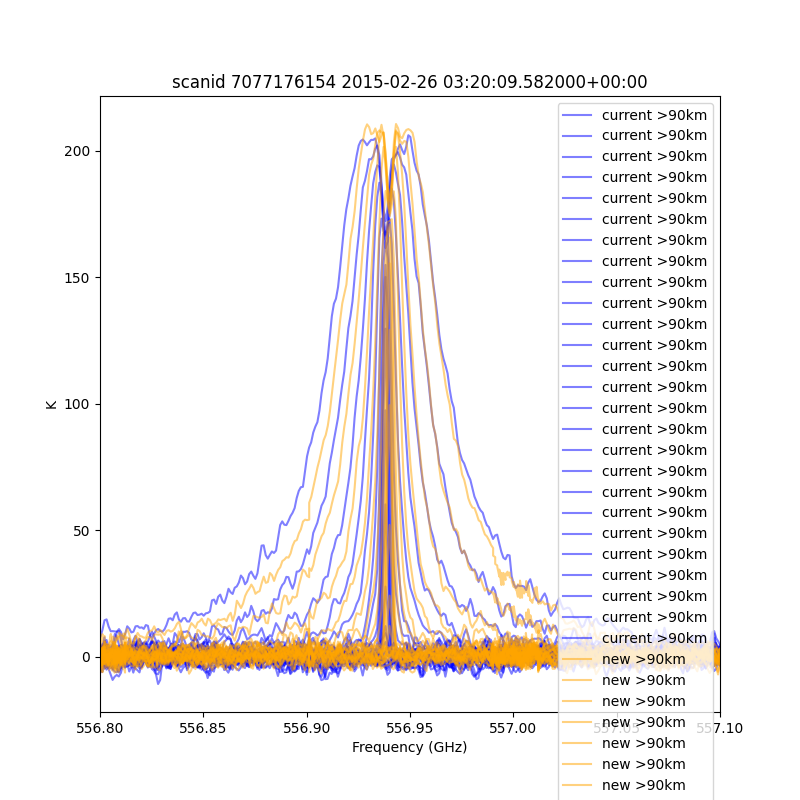

In [14]:
low_mask = (l1.specs.loc[stw1:stw2].t_height > 60).to_numpy()
low_mask_db = alt > 60000
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[low_mask_db][:, None] + if_freq[None, :]).T / 1e9,
    data[low_mask_db].T,
    alpha=0.5,
    color="blue",
    label="current >90km",
    # marker="+",
    # ls="none",
)
ax.plot(
    x[low_mask].T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y[low_mask].T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    color="orange",
    label="new >90km",
)

ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"scanid {stw1} {l1.attitude.datetime.loc[stw1]}")
ax.set_ylabel("K")
ax.set_xlim(556.8,557.1)
# ax.set_ylim(150,260)
plt.show()

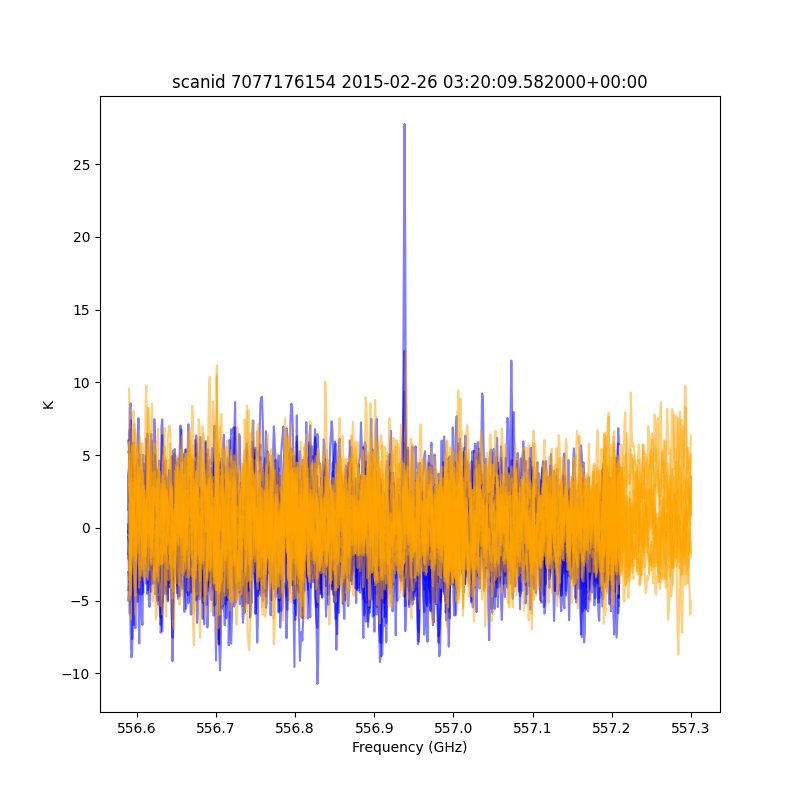

In [15]:
low_mask = (l1.specs.loc[stw1:stw2].t_height > 95).to_numpy()
low_mask_db = alt > 95000
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[low_mask_db][:, None] + if_freq[None, :]).T / 1e9,
    data[low_mask_db].T,
    alpha=0.5,
    color="blue",
    label="current >90km",
    # marker="+",
    # ls="none",
)
ax.plot(
    x[low_mask].T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y[low_mask].T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    color="orange",
    label="new >90km",
)

# ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"scanid {stw1} {l1.attitude.datetime.loc[stw1]}")
ax.set_ylabel("K")
# ax.set_xlim(556.8,557.1)
# # ax.set_ylim(150,260)
plt.show()

In [16]:
l1.attitude.vgeo.to_numpy().min(),l1.attitude.vgeo.to_numpy().max()

AttributeError: 'DataFrame' object has no attribute 'vgeo'